In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris/Iris.csv
/kaggle/input/iris/database.sqlite


# EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/iris/Iris.csv')
df.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [4]:
df.tail(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
140,141,6.7,3.1,5.6,2.4,Iris-virginica
141,142,6.9,3.1,5.1,2.3,Iris-virginica
142,143,5.8,2.7,5.1,1.9,Iris-virginica
143,144,6.8,3.2,5.9,2.3,Iris-virginica
144,145,6.7,3.3,5.7,2.5,Iris-virginica
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df.isnull().any().values

array([False, False, False, False, False, False])

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,150.0,75.500000,43.445368,1.0,38.25,75.50,112.75,150.0
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.10,5.80,6.40,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.80,3.00,3.30,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.60,4.35,5.10,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.30,1.30,1.80,2.5


In [8]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

# Visualization

In [9]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = df.drop("Id", axis = 1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


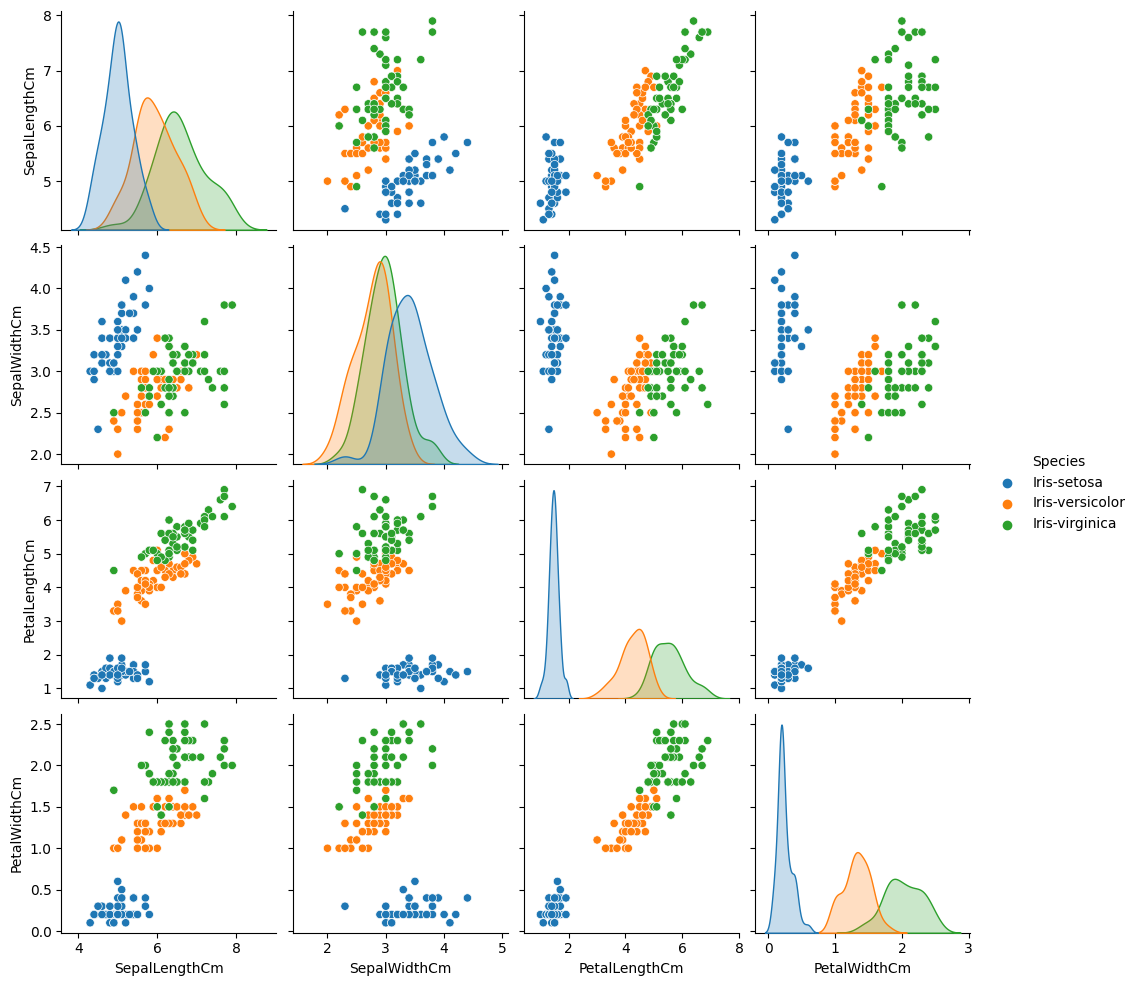

In [11]:
#pairplot
pair_plot = sns.pairplot(df, hue = "Species")
plt.show()

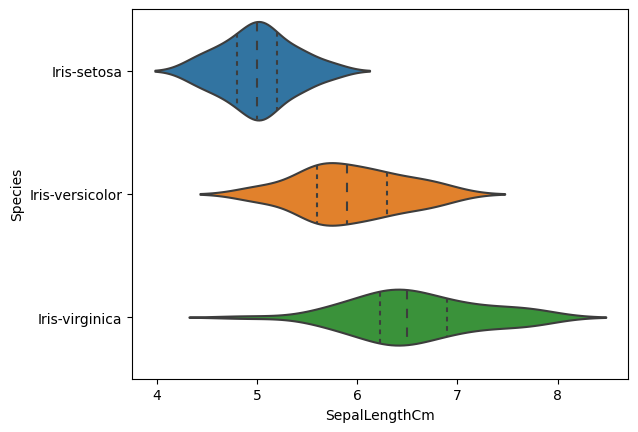

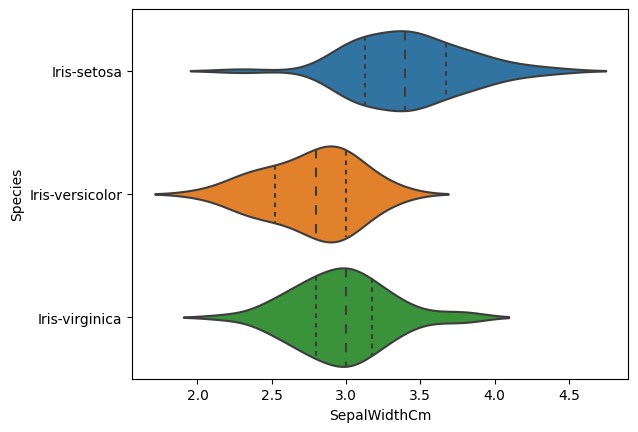

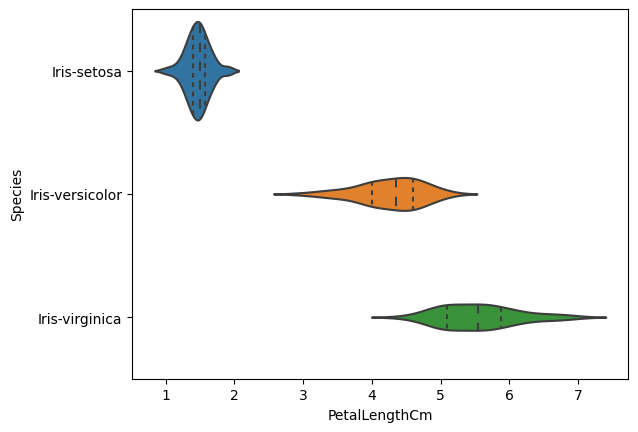

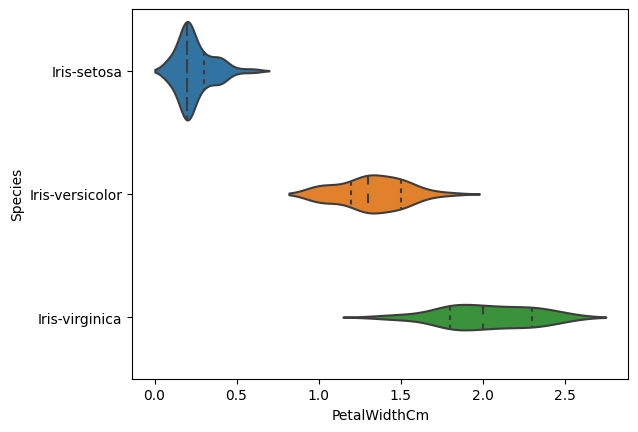

In [12]:
violin_sepal_length = sns.violinplot(y='Species', x='SepalLengthCm', data=df, inner='quartile')
plt.show()
violin_sepal_width = sns.violinplot(y='Species', x='SepalWidthCm', data=df, inner='quartile')
plt.show()
violin_petal_length = sns.violinplot(y='Species', x='PetalLengthCm', data=df, inner='quartile')
plt.show()
violin_petal_width = sns.violinplot(y='Species', x='PetalWidthCm', data=df, inner='quartile')
plt.show()

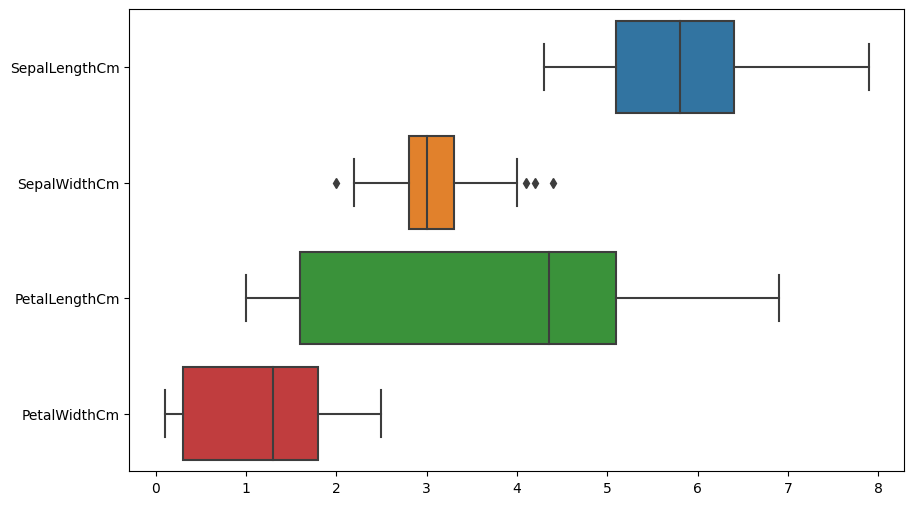

In [13]:
#outlier 
plt.figure(figsize=(10, 6))  
sns.boxplot(data=df, orient='h')  
plt.show()

In [14]:
out=[]
def iqr_outliers(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3-Q1
    Lower_tail = Q1 - 1.5 * IQR
    Upper_tail = Q3 + 1.5 * IQR
    for i in df:
        if i > Upper_tail or i < Lower_tail:
            out.append(i)
    print("Outliers:",out)
iqr_outliers(df['SepalWidthCm'])

Outliers: [4.4, 4.1, 4.2, 2.0]


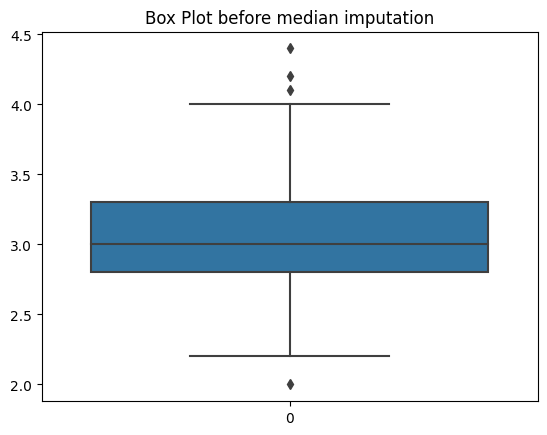

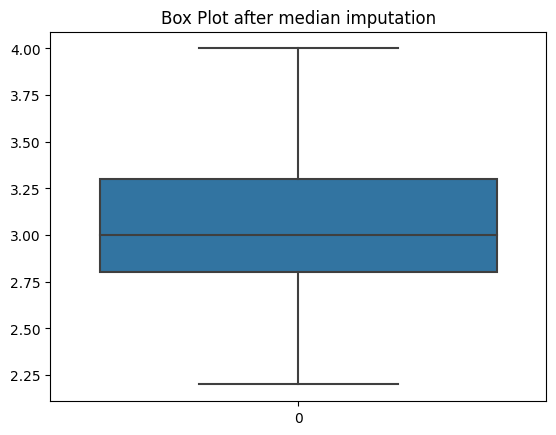

In [15]:
#median imputation
sns.boxplot(df['SepalWidthCm'])
plt.title("Box Plot before median imputation")
plt.show()

Q1 = df['SepalWidthCm'].quantile(0.25)
Q3 = df['SepalWidthCm'].quantile(0.75)
IQR = Q3 - Q1
Lower_tail = Q1 - 1.5 * IQR
Upper_tail = Q3 + 1.5 * IQR

sepal_median = np.median(df['SepalWidthCm'])

for i in df['SepalWidthCm']:
    if i > Upper_tail or i < Lower_tail:
            df['SepalWidthCm'] = df['SepalWidthCm'].replace(i, sepal_median)

sns.boxplot(df['SepalWidthCm'])
plt.title("Box Plot after median imputation")
plt.show()          

# KNN 

In [16]:
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [17]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [18]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
y = df["Species"]

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42)

In [20]:
knn = KNeighborsClassifier()
knn_model = knn.fit(X_train, y_train)

In [21]:
y_pred = knn_model.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [22]:
#model tuning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict

knn_params = {"n_neighbors": np.arange(1,50)}

knn = KNeighborsClassifier()

knn_cv = GridSearchCV(knn, knn_params, cv=10)
knn_cv.fit(X_train, y_train)

print("The best score: " + str(knn_cv.best_score_))
print("The best parameters: " + str(knn_cv.best_params_))

The best score: 0.9627272727272727
The best parameters: {'n_neighbors': 11}


In [23]:
knn = KNeighborsClassifier(11)
knn_tuned = knn.fit(X_train, y_train)

In [24]:
knn_tuned.score(X_test, y_test)

1.0

In [25]:
y_pred = knn_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

# Decision Tree

test accuracy: 1.0
train accuracy: 1.0


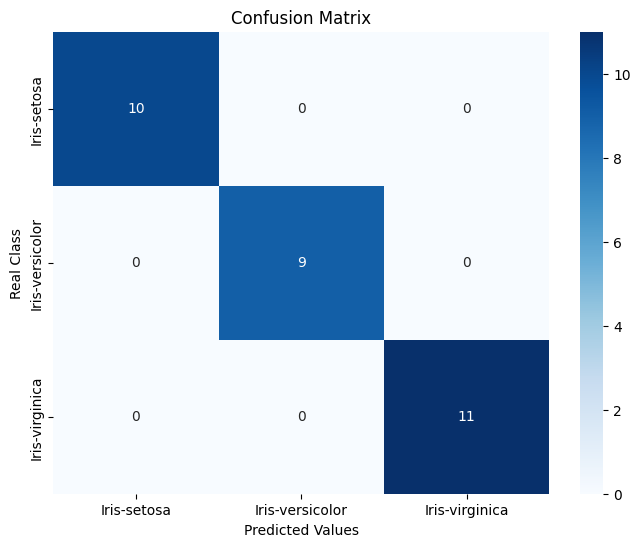

In [26]:
from sklearn.model_selection import train_test_split  
from sklearn.tree import DecisionTreeClassifier, plot_tree  
from sklearn.metrics import accuracy_score, confusion_matrix  

import matplotlib.pyplot as plt  
import seaborn as sns  
import pandas as pd  

X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]  
y = df["Species"]  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  

tree_clf = DecisionTreeClassifier(criterion="gini", max_depth=30, random_state=42)  
tree_clf.fit(X_train, y_train)  

y_pred = tree_clf.predict(X_test)  
accuracy = accuracy_score(y_test, y_pred)  
print(f"test accuracy: {accuracy}")  

y_pred_train = tree_clf.predict(X_train)  
accuracy_train = accuracy_score(y_train, y_pred_train)  
print(f"train accuracy: {accuracy_train}")  
 
conf_matrix = confusion_matrix(y_test, y_pred)  
 
plt.figure(figsize=(8, 6))  
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="g",  
            xticklabels=tree_clf.classes_,  
            yticklabels=tree_clf.classes_)  

plt.xlabel("Predicted Values")  
plt.ylabel("Real Class")  
plt.title("Confusion Matrix")  
plt.show()

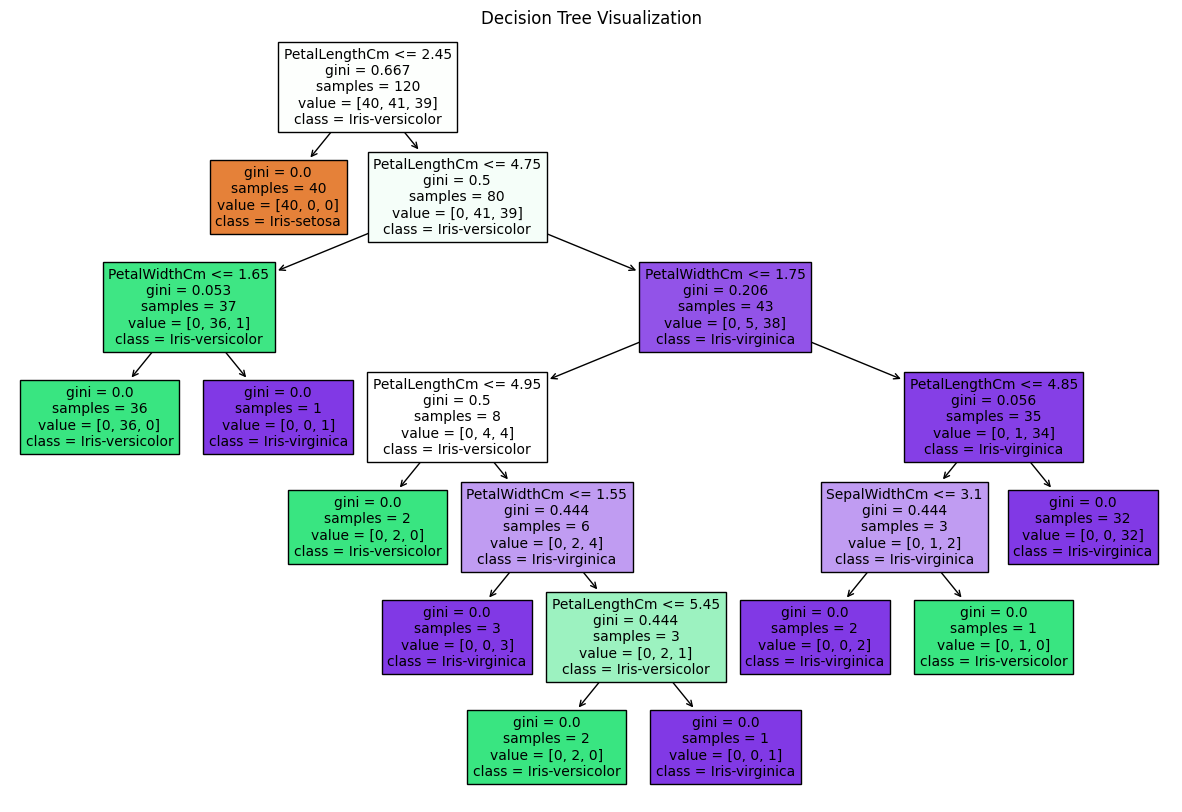

PetalLengthCm: 0.9061433868879218
PetalWidthCm: 0.07718647349965893
SepalWidthCm: 0.016670139612419255
SepalLengthCm: 0.0


In [27]:
plt.figure(figsize=(15, 10))  
plot_tree(tree_clf, filled=True,   
          feature_names=X.columns,  
          class_names=tree_clf.classes_)    

plt.title("Decision Tree Visualization")  
plt.show()  # Grafiği göster  

feature_importances = tree_clf.feature_importances_  

feature_names = X.columns  

feature_importance_sorted = sorted(zip(feature_importances, feature_names), reverse=True)  

for importance, feature_name in feature_importance_sorted:  
    print(f"{feature_name}: {importance}")